In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.imports import *

---
### Unlabel folder
---

In [3]:
unlabeled_path = os.path.join(DATASET_DIR_BHSD, UNLABELED_FOLDER_BHSD)
files = os.listdir(unlabeled_path)
for file in files:
    print(file, ":" , len(os.listdir(os.path.join(unlabeled_path, file))))

anybleed : 562
nobleed : 1418


---
### Label folder
---

In [4]:
label_path = os.path.join(DATASET_DIR_BHSD, LABEL_FOLDER_BHSD)
files = os.listdir(label_path)
for file in files:
    print(file, ":" , len(os.listdir(os.path.join(label_path, file))))

ground truths : 192
images : 192


In [5]:

unlabeled_path = os.path.join(DATASET_DIR_BHSD, UNLABELED_FOLDER_BHSD)
rows = []

for folder in os.listdir(unlabeled_path):
    folder_path = os.path.join(unlabeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,anybleed,562,.nii.gz
1,nobleed,1418,.nii.gz


In [6]:

labeled_path = os.path.join(DATASET_DIR_BHSD, LABEL_FOLDER_BHSD)
rows = []

for folder in os.listdir(labeled_path):
    folder_path = os.path.join(labeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,ground truths,192,.nii.gz
1,images,192,.nii.gz


In [7]:
file_path = os.path.join(labeled_path, "ground truths")
file = os.path.join(file_path, "ID_0b10cbee_ID_f91d6a7cd2.nii.gz")
nii_img = nib.load(file)
data = nii_img.get_fdata()
header = nii_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 512 512  32   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.488281   0.488281   5.2284584  0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0
quatern_c       : 0.9890158
quatern_d       : 0.147

In [39]:
# write the get_file_path function for the below code to work
# Error:
# ---------------------------------------------------------------------------
# TypeError                                 Traceback (most recent call last)
# Cell In[37], line 1
# ----> 1 view_random_sample_with_mask()

# Cell In[36], line 20
#      17 random_file = random.choice(all_files)
#      19 # visualize with mask
# ---> 20 view_single(random_file, window=window, overlay=True, mask_color="red", alpha=0.4, base_dir=base_dir)

# Cell In[33], line 17
#      15 mask_slices = None
#      16 if overlay:
# ---> 17     mask_path = get_file_path(filename, subfolder=MASKS_FOLDER)
#      18     if os.path.exists(mask_path):
#      19         mask_data, _ = load_nifti(mask_path)

# TypeError: get_file_path() got an unexpected keyword argument 'subfolder'
def get_file_path(filename, subfolder=None):
    if subfolder is None:
        subfolder = "images"
    return os.path.join(DATASET_DIR_BHSD, LABEL_FOLDER_BHSD, subfolder, filename)

In [40]:
# ...existing code...
def view_single(filename, window=None, overlay=False,
                mask_color="red", alpha=0.4, base_dir=None):

    # determine CT path (use provided base_dir or dataset constants)
    if base_dir is None:
        base_dir = os.path.join(os.path.join(DATASET_DIR_BHSD, LABEL_FOLDER_BHSD), "images")
    ct_path = os.path.join(base_dir, filename)

    # load CT
    data, zooms = load_nifti(ct_path)

    # load mask if requested
    mask_data = None
    mask_slices = None
    if overlay:
        mask_path = get_file_path(filename, subfolder=MASKS_FOLDER)
        if os.path.exists(mask_path):
            mask_data, _ = load_nifti(mask_path)
            mask_slices = get_mid_slices(mask_data)

    # window
    vmin, vmax, window_str = compute_window(window)

    # slices
    ct_slices = get_mid_slices(data)

    aspects = {
        "Sagittal": zooms[2] / zooms[1],
        "Coronal":  zooms[2] / zooms[0],
        "Axial":    zooms[1] / zooms[0],
    }

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, view_name in zip(axes, ct_slices.keys()):
        mask_for_view = None
        if mask_slices and view_name in mask_slices:
            mask_for_view = mask_slices[view_name]

        draw_slice(
            ax,
            ct_slices[view_name],
            mask_for_view,
            aspect=aspects[view_name],
            vmin=vmin,
            vmax=vmax,
            mask_color=mask_color,
            alpha=alpha
        )

        ax.set_title(view_name)

    # metadata
    shape_str = f"Shape: {data.shape}"
    zoom_str = f"Voxel: {zooms[0]:.3f} x {zooms[1]:.3f} x {zooms[2]:.3f} mm"
    file_str = f"File: {os.path.basename(ct_path)}"

    fig.suptitle(
        f"{file_str}\n{shape_str}\n{zoom_str}\n{window_str}",
        fontsize=11
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.83)
    plt.show()
# ...existing code...

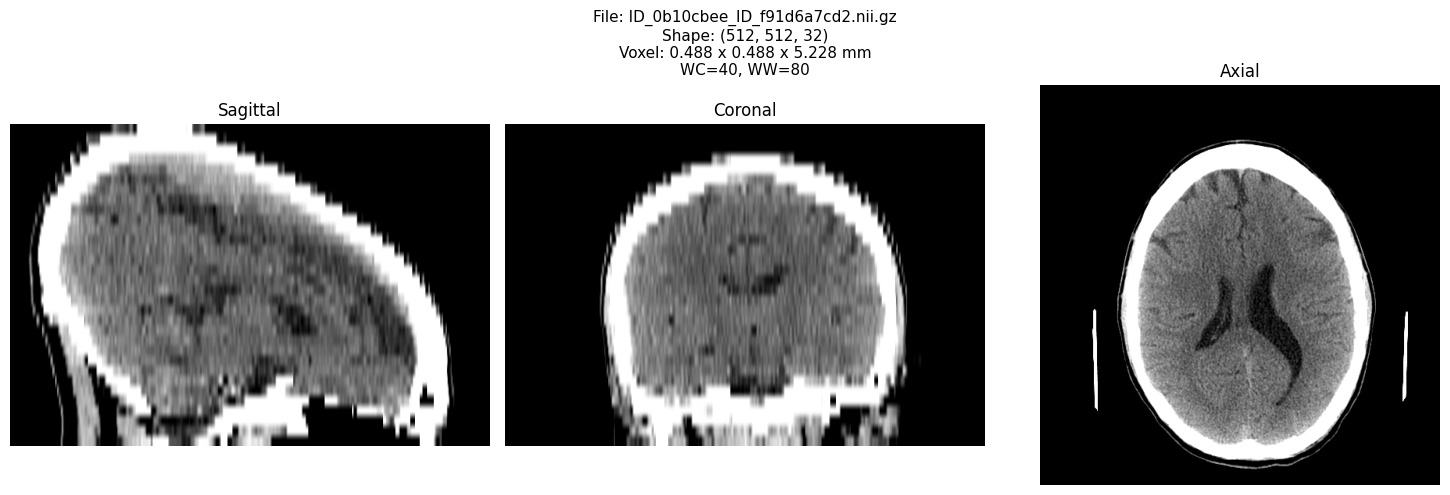

In [41]:
view_single("ID_0b10cbee_ID_f91d6a7cd2.nii.gz", (40, 80))

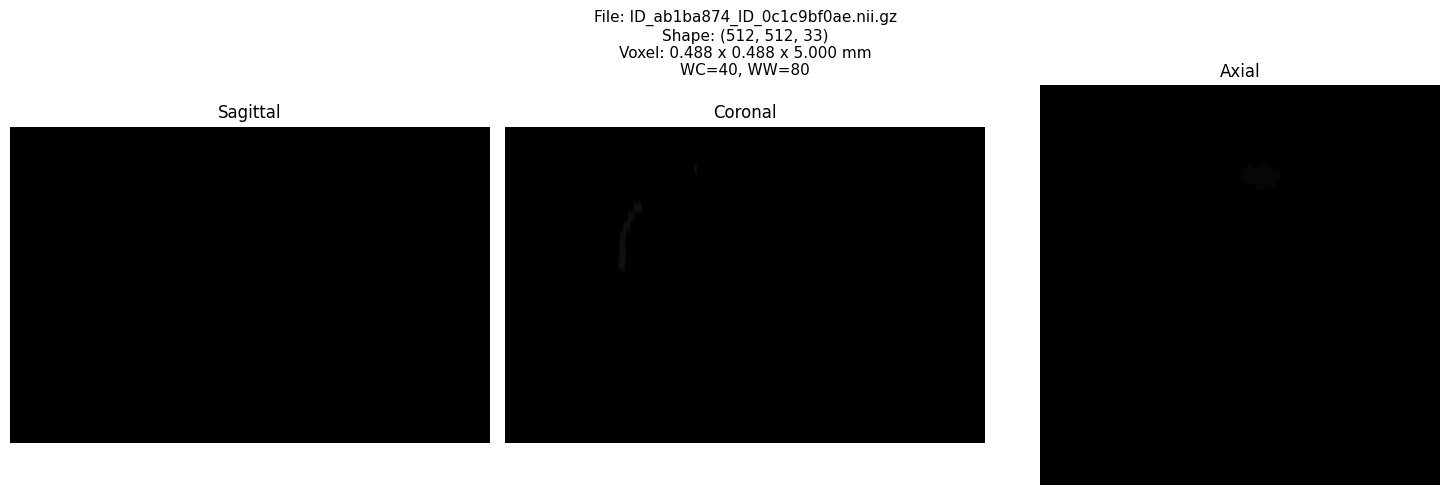

In [42]:
def view_random_sample(base_dir=None, window=(40, 80), overlay=False):
    if base_dir is None:
        base_dir = os.path.join(DATASET_DIR_BHSD, LABEL_FOLDER_BHSD, "ground truths")

    # lấy tất cả file nii.gz
    all_files = [
        f for f in os.listdir(base_dir)
        if f.endswith(".nii.gz")
    ]

    if not all_files:
        print("No files found in the dataset.")
        return

    # random file
    random_file = random.choice(all_files)

    # visualize
    view_single(random_file, window=window, overlay=overlay, base_dir=base_dir)


view_random_sample()

In [43]:
# Write another function just like view_random_sample but have color mask red and alpha 0.4 by default
def view_random_sample_with_mask(base_dir=None, window=(40, 80)):
    if base_dir is None:
        base_dir = os.path.join(DATASET_DIR_BHSD, LABEL_FOLDER_BHSD, "ground truths")

    # lấy tất cả file nii.gz
    all_files = [
        f for f in os.listdir(base_dir)
        if f.endswith(".nii.gz")
    ]

    if not all_files:
        print("No files found in the dataset.")
        return

    # random file
    random_file = random.choice(all_files)

    # visualize with mask
    view_single(random_file, window=window, overlay=True, mask_color="red", alpha=0.4, base_dir=base_dir)

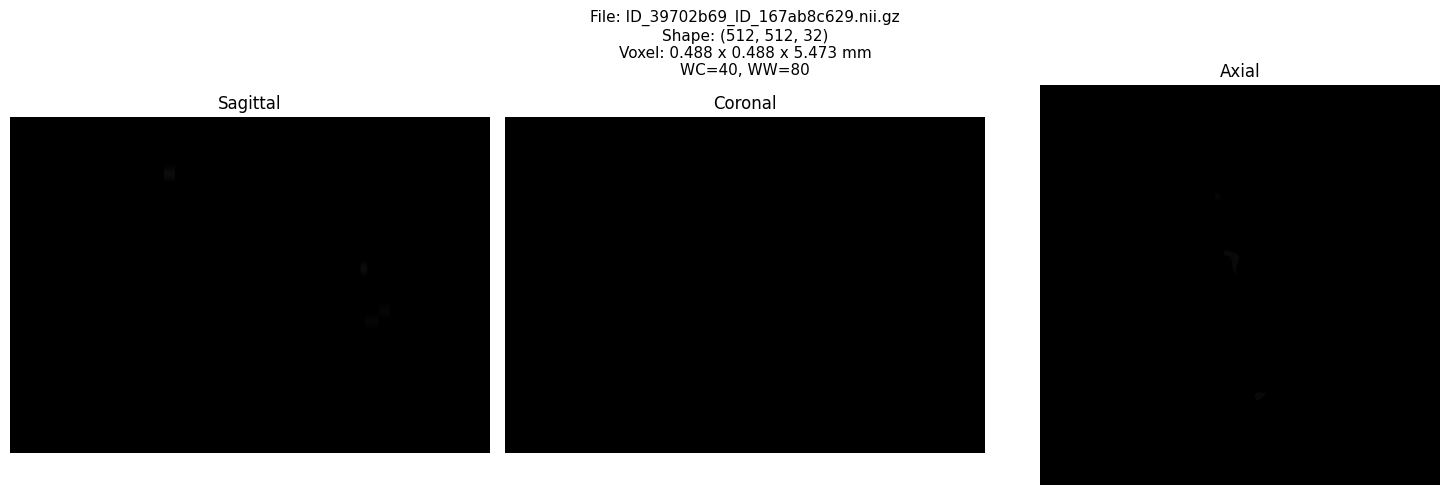

In [48]:
view_random_sample_with_mask()